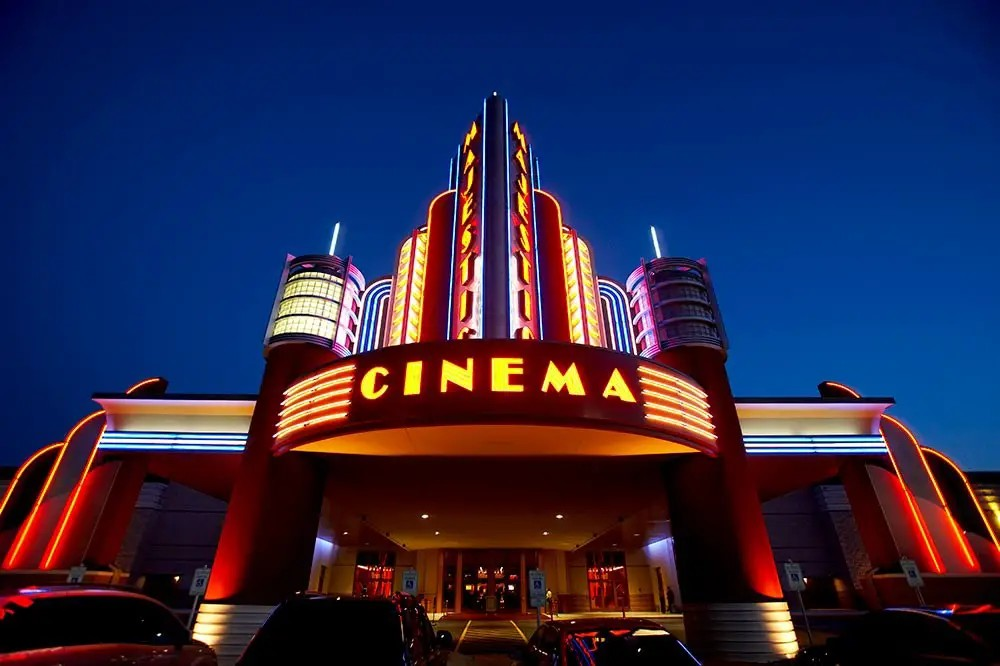

In [91]:
# add notebook image
from IPython.display import Image, display

display(Image(filename='images/cinema_02.jpg'))

# 🛠️ **GROUP ONE PROJECT**.

**Authors**: _Patrick Maina(Group leader), Teresia Njoki, Christine Ndungu, George Nyandusi._

**Class:** DSFT12- Fulltime/hybrid, Phase 2

**Instuctor:** Nikita Njoroge

# 📽️ **Box Office Analysis For New Movie Studio**
Generating data-driven insights for establishing a new film studio.

## **Overview** 💼

In the evolving entertainment landscape, major companies are increasingly investing in original movie content to capture audience attention and drive growth. Our company is now launching a new movie studio to enter this competitive market. However, without prior experience in film production, strategic, data-driven insights are critical to ensuring our success.
This project explores movie industry data to uncover what factors drive box office success, helping us recommend the types of movies our new studio should prioritize.

## **Problem Statement** 📝
The company seeks to determine which factors most influence film commercial success, and derive insights into blockbuster film production, marketing (domestic and international), and release strategies, which will be crucial in development of the new studio.

## **Project Goals** 🎯
1. Collect and investigate the box office database and datasets.

2. Determine which movie genres (e.g., action, adventure, family) have historically performed best.

3. Examine domestic vs international box office trends.

4. Perform Exploratory Data Analysis (EDA) and identify key attributes that influence box office success.

5. Offer clear, data-driven recommendations to support film production planning and market positioning.

## **Challenges** ⚠️
Some of the key challenges faced in analyzing the box office industry and establishing a film studio include:
1. Uncertainty in establishing the genres, budgets, and release timings that lead to box office success

2. Lack of internal historical data and experience in film production

3. The need to differentiate between domestic and international market dynamics.

## **Proposed Solution** 🧠
This project aims to identify the factors most associated with box office breakthroughs by analyzing data from different sources such as Box Office Mojo, IMDb, and The Numbers. The solution entails developing a comprehensive pipeline—from data gathering, cleaning, and Exploratory Data Analysis (EDA) to extracting data-driven insights and recommendations that will support robust decision-making.

## **Data Understanding** 📁
We will be working with real-world datasets collected from:
### 1. **Box Office Mojo.**
- Gross earnings data, we understand how much money movies actually made.

- Provides detailed information about movies' domestic and international box office revenues.

### 2. **IMDb.**
- Offers information on genres, movie titles, release dates, runtime, and audience ratings.

- This will help us analyze how movie content and quality relate to success.

### 3. **The Numbers**
- Provides production budget estimates and deeper financial metrics/statistics.

- This is crucial to finding out how much was spent to make the movies and whether it paid off.

🎞️ Some of the main attributes that will be used in analysis fron the data include:
- Movie title

- Genre(s)

- Box office earnings

- Release year

- IMDb rating

- Number of audience votes

Specifically, we will be working with the following datasets:
- `bom.movie_gross.csv`: Gross earnings (domestic and international).

- `im.db` SQLite database:
    - `movie_basics` table: Contains movie title, genre, runtime, and release year.
    - `movie_ratings` table: Contains average IMDb ratings and number of votes.

## **Workflow Overview 📊**
1. ### **Understand the Business Problem** 📝
- Define the key questions and success criteria for the new movie studio.

- Review what the company needs: actionable insights on what kind of movies to produce, and how to position them.

  **Examples**:
    - What types of movies (genre, style, content) are doing well at the box office?

    - When should these movies be released to get the best audience response?

    - Should they prioritize domestic (local) markets or international markets for their success?

2. ### **Data Acquisition and Familiarization** 🗃️
- Collect and explore datasets from the different data sources

- Inspect key attributes like movie genres, runtime, box office earnings, production budgets, release years, and audience ratings.

3. ### **Data Cleaning and Preparation** 📂
- Handle missing and inconsistent values, remove duplicates.

- Standardize formats across datasets.

- Feature Engineering (e.g., adding a new column `total_gross`, which is a sum of domestic and foreign revenues).

4. ### **Exploratory Data Analysis (EDA)** 📈
- Visualize and investigate trends between genres, budgets, ratings, and earnings.

- Implement correlation heatmaps, bar plots, histograms, and line plots to derive data-driven insights and recommendations.

5. ### **Hypothesis Testing** ❓
- Conduct statistical tests to validate or reject assumptions such as:
    - Do higher-budget films consistently outperform low-budget ones?

    - Do some genres consistently earn higher ratings than others?

    - Do longer movies tend to receive higher ratings?

- Visualize the tests using a box plot and a regression plot.

6. ### **Insights and Recommendations** 💬
- Summarize findings to recommend such as:
    - Top genres and budgets to focus on.

    - Ideal release windows.

    - Audience segments to target.

## **Conclusion** 📤
This analysis will empower the new studio with strategic recommendations on genre selection, ideal release timing, and target audience segmentation, maximizing the chances of producing profitable films and generating decent revenue, both domestically and globally.


Now that we have an understanding of the project, let's dive into the code! 🚀

In [92]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sqlite3

# Set the seaborn plot size
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

### **Load the Datasets**
In this project, we will be utilizing the:
- `im.db` SQL Database
- `bom.movie_gross.csv` CSV Dataset
for our analysis. 

The code below connects to the SQL database, and reads the contents in the database.

In [93]:
# connect to the SQLite database
conn = sqlite3.connect('data/im.db')

# view the tables in the database
q_read_data = """SELECT name 
                 FROM sqlite_master 
                 WHERE type='table';"""
pd.read_sql(q_read_data, conn)

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


The `im.db` database contains a number of tables, which include:
- movie_basics
- directors
- known_for
- movie_akas
- movie_ratings
- persons
- principals
- writers

In [94]:
# read data from movie_basics table
q_movie_basics = """SELECT *
                    FROM movie_basics;"""
movie_basics_df = pd.read_sql(q_movie_basics, conn)
movie_basics_df.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [95]:
# check the info of the movie_basics_df
movie_basics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146144 entries, 0 to 146143
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   movie_id         146144 non-null  object 
 1   primary_title    146144 non-null  object 
 2   original_title   146123 non-null  object 
 3   start_year       146144 non-null  int64  
 4   runtime_minutes  114405 non-null  float64
 5   genres           140736 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 6.7+ MB


The `movie_basics` table contains a total of 146,144 entries, and a total of 6 columns, including **movie_id, primary_title, original_title, start_year, runtime_minutes, and genres**

In [96]:
# read from the movie_ratings table
q_movie_ratings = """SELECT *
                     FROM movie_ratings;"""
movie_ratings_df = pd.read_sql(q_movie_ratings, conn)
movie_ratings_df.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [97]:
# check the info of the dataframe
movie_ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       73856 non-null  object 
 1   averagerating  73856 non-null  float64
 2   numvotes       73856 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.7+ MB


The `movie_ratings` table contains a total of 73856 entries, with a total of 3 columns, including **movie_id, averagerating, and numvotes**.

In the database, we can combine the `movie_basics` and `movie_ratings` since they share a common column, which is **movie_id**

In [98]:
# join the movie_basics_df & movie_ratings_df dataframes using pandas
movie_df = pd.merge(movie_basics_df, movie_ratings_df, on='movie_id', how='inner')
movie_df.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama,6.9,4517
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama",6.1,13
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy",6.5,119


In [99]:
# check the info of the movie_df
movie_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         73856 non-null  object 
 1   primary_title    73856 non-null  object 
 2   original_title   73856 non-null  object 
 3   start_year       73856 non-null  int64  
 4   runtime_minutes  66236 non-null  float64
 5   genres           73052 non-null  object 
 6   averagerating    73856 non-null  float64
 7   numvotes         73856 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 4.5+ MB


The merged dataframe has a total of `73856` records from the two tables, and a total of `8` columns.

Next, we load the bom.movie_gross.csv dataset.

In [100]:
# load the movie_gross dataset
movie_gross_df = pd.read_csv('data/bom.movie_gross.csv')
movie_gross_df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [101]:
# check the info of the movie_gross_df
movie_gross_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


The `.info()` function provides a general summary of the dataframe, giving details like:
- Total number of **entries**(rows)
- The range of entries (0 to 3386)
- Total number of **columns**
- Total number of non-null values
- Data types for each column:
    - `object` -> for string
    - `int64` -> for integers
    - `float64` -> for floating point integers
This information aids in detecting missing data and determining whether columns require standardization.

The `movie_gross` dataframe has a total of `3387` records, and a total of `5` columns.

From the information, we can see that **foreign_gross** is displayed as an object data type. We can convert it to its correct data type, which is float.

In [102]:
# convert the foreign_gross column to numeric
movie_gross_df['foreign_gross'] = movie_gross_df['foreign_gross'].replace(",", "", regex=True).astype(float)

# display the first 5 rows
print(movie_gross_df['foreign_gross'].head())

0    652000000.0
1    691300000.0
2    664300000.0
3    535700000.0
4    513900000.0
Name: foreign_gross, dtype: float64


In [103]:
# summary statistics for movie_df
movie_df.describe()

,start_year,runtime_minutes,averagerating,numvotes
count,73856.000000,66236.000000,73856.000000,7.385600e+04
mean,2014.276132,94.654040,6.332729,3.523662e+03
std,2.614807,208.574111,1.474978,3.029402e+04
min,2010.000000,3.000000,1.000000,5.000000e+00
25%,2012.000000,81.000000,5.500000,1.400000e+01
50%,2014.000000,91.000000,6.500000,4.900000e+01
75%,2016.000000,104.000000,7.400000,2.820000e+02
max,2019.000000,51420.000000,10.000000,1.841066e+06


In [104]:
# summary statistics for movie_gross_df
movie_gross_df.describe()

,domestic_gross,foreign_gross,year
count,3.359000e+03,2.037000e+03,3387.000000
mean,2.874585e+07,7.487281e+07,2013.958075
std,6.698250e+07,1.374106e+08,2.478141
min,1.000000e+02,6.000000e+02,2010.000000
25%,1.200000e+05,3.700000e+06,2012.000000
50%,1.400000e+06,1.870000e+07,2014.000000
75%,2.790000e+07,7.490000e+07,2016.000000
max,9.367000e+08,9.605000e+08,2018.000000


The `.describe()` function provides summary statistics for numeric columns in the dataframes. It provides details such as:
- **count**: total number of nun-null records
- **mean**: Average value of each column
- **std (standard deviation)**: how spread out the values are
- **min**: Minimum value
- **25%**: 25th Percentile
- **50%**: median(mid value)
- **75%**: 75th percentile
- **max**: Maximum value 

From the `info()` function, we have seen there are missing values in both dataframes. We can check how many missing values are present in each column in the dataframes. 

In [105]:
# check for null values in movie_df
print(movie_df.isnull().sum())

movie_id              0
primary_title         0
original_title        0
start_year            0
runtime_minutes    7620
genres              804
averagerating         0
numvotes              0
dtype: int64


In [106]:
# check for null values in movie_gross_df
print(movie_gross_df.isnull().sum())

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64


## **Data Cleaning**
### Movie_df Data Cleaning
In this dataframe, we will deal with the missing values by:
- Filling missing `runtime_minutes` values with the median
- Filling missing `genres` with the string **"Unknown"**

In [107]:
# movie_df data cleaning
def clean_movie_df(df):
    # fill missing values in 'genres' with unknown
    movie_df['genres'].fillna('Unknown', inplace=True)

    # fill missing values in 'runtime_minutes' with the median
    runtime_median = movie_df['runtime_minutes'].median()
    movie_df['runtime_minutes'].fillna(runtime_median, inplace=True)
    
    return df

In [108]:
# call the function to clean the movie_df
clean_movie_df(movie_df)

# re-check for null values in movie_df
print("Null values after cleaning:")
print(movie_df.isnull().sum())

Null values after cleaning:
movie_id           0
primary_title      0
original_title     0
start_year         0
runtime_minutes    0
genres             0
averagerating      0
numvotes           0
dtype: int64


/tmp/ipykernel_220592/3246817316.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_df['genres'].fillna('Unknown', inplace=True)
/tmp/ipykernel_220592/3246817316.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

### Movie_gross Data Cleaning
In this dataframe, we will deal with missing values by:
- Drop the rows in `studio` and `domestic_gross` with missing values
- Filling the `foreign_gross` column with the median

In [109]:
# movie_gross_df data cleaning
def clean_movie_gross(df):

    # drop rown in 'studio' and 'domestic_gross'
    movie_gross_df.dropna(subset=['studio', 'domestic_gross'], inplace=True, axis=0)

    # fill the 'foreign_gross' column with median
    median_gross = movie_gross_df['foreign_gross'].median()
    movie_gross_df['foreign_gross'].fillna(median_gross, inplace=True)

    return df

In [110]:
# call the function to clean the movie_gross_df
clean_movie_gross(movie_gross_df)

# re-check for null values in movie_gross_df
print("Null values after cleaning:")
print(movie_gross_df.isnull().sum())

Null values after cleaning:
title             0
studio            0
domestic_gross    0
foreign_gross     0
year              0
dtype: int64


/tmp/ipykernel_220592/3079501367.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_gross_df['foreign_gross'].fillna(median_gross, inplace=True)


### **Standardizing Column Names**
Next, we can standardize the columns in each dataframe to ensure readability and uniformity across dataframes. We can do this using the following methods:
- `str.strip()`: used to remove any trailing whitespace in a string
- `str.lower()`: used to convert a string to lowercase
- `str.replace()`: used to replace characters in a string

In [111]:
# standardize column names in movie_df
movie_df.columns = (
    movie_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
# replace 'averagerating' and 'numvotes'
movie_df = movie_df.rename(
    columns = {
        'averagerating': 'average_rating',
        'numvotes': 'number_of_votes'
    }
)

print("Standardized column names in movie_df: ", movie_df.columns.tolist())

# standardize column names in movie_gross_df
movie_gross_df.columns = (
    movie_gross_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
print("Standardized column names in movie_gross_df: ", movie_gross_df.columns.tolist())

Standardized column names in movie_df:  ['movie_id', 'primary_title', 'original_title', 'start_year', 'runtime_minutes', 'genres', 'average_rating', 'number_of_votes']
Standardized column names in movie_gross_df:  ['title', 'studio', 'domestic_gross', 'foreign_gross', 'year']


### **Data Integrity**
In order to confirm that our dataframes are in the correct format:
- We'll check for missing values in the resulting `movie_df` and `movie_gross_df` dataframes using `.isnull().sum()`
- We'll check for duplicate records in both dataframes using `.duplicated().sum()`
- We'll check for the data types of each column in the Dataframes using `.dtypes`

In [112]:
# function to perform data integrity
def data_integrity():
    # check missing values in movie_df & movie_gross_df
    print(f"Missing values in movie_df\n: {movie_df.isnull().sum()}")
    print(f"Missing values in movie_gross_df:\n {movie_gross_df.isnull().sum()}")

    # check duplicate records in movie_df & movie_gross_df
    print(f"Duplicate records in movie_df: {movie_df.duplicated().sum()}")
    print(f"Duplicate records in movie_gross_df: {movie_gross_df.duplicated().sum()}")

    # check the data types of each column in movie_df & movie_gross_df
    print(f"Column data types in movie_df:\n {movie_df.dtypes}")
    print(f"Column data types in movie_gross_df:\n {movie_gross_df.dtypes}")

# call the data integrity function for movie_df
data_integrity()

Missing values in movie_df
: movie_id           0
primary_title      0
original_title     0
start_year         0
runtime_minutes    0
genres             0
average_rating     0
number_of_votes    0
dtype: int64
Missing values in movie_gross_df:
 title             0
studio            0
domestic_gross    0
foreign_gross     0
year              0
dtype: int64


Duplicate records in movie_df: 0
Duplicate records in movie_gross_df: 0
Column data types in movie_df:
 movie_id            object
primary_title       object
original_title      object
start_year           int64
runtime_minutes    float64
genres              object
average_rating     float64
number_of_votes      int64
dtype: object
Column data types in movie_gross_df:
 title              object
studio             object
domestic_gross    float64
foreign_gross     float64
year                int64
dtype: object


### **Saving the cleaned Dataframes**
Finally, we will save the movie_df and movie_gross_df dataframes to separate CSV files for further EDA analysis.

In [113]:
# save to a csv file
movie_df.to_csv('data/cleaned_data/cleaned_movie_dataset.csv')
movie_gross_df.to_csv('data/cleaned_data/cleaned_movie_gross_dataset.csv')

## **EXPLORATORY DATA ANALYSIS (EDA)** 📊
- Performing Exploratory Data Analysis aids in determining attributes that influence aspects such as revenue, which include genre, average rating, runtime minutes, etc.
- It also helps in visually presenting our findings to stakeholders, which in turn provides suitable data-driven recommendations that will assist in the establishment of a movie studio.

- From the `movie_df` dataset, we are able to provide visualizations that answer some of the following questions:
    - Which genres have the highest average ratings?
    - Does the movie runtime affect the movie average rating?
    - What is the trend in number of movies released in a year?
    - What is the most common average rating for the most number of movies?
    - What is the correlation between some of the attributes such as `average_rating, number_of_votes, runtime_minutes`

- From the `movie_gross_df` dataset, we are able to provide visualizations that answer some of the following questions:
    - What are some of the top movies by revenue (domestic & foreign gross)
    - What are some of the top movie genres by the average domestic gross
    - Which years generated the highest revenue
    - Which production studios had the highest domestic and foreign revenues
    - What is the correlation between some of the attributes such as `domestic_gross, foreign_gross, and total_gross(new column)`

In [114]:
# load the cleaned dataset for analysis
movie_df = pd.read_csv('data/cleaned_data/cleaned_movie_dataset.csv')
movie_gross_df = pd.read_csv('data/cleaned_data/cleaned_movie_gross_dataset.csv')

### **Feature Engineering**
To further carry out our analysis, we would like to create a new column `total_gross` in the `movie_gross_df` dataframe. This will aid in determining the total revenue for each movie, both domestic and foreign.

To do this, we get the summation of the `domestic_gross` and `foreign_gross` columns. We will then check the first 5 rows of the column to confirm that the addition has occurred successfully.

In [115]:
# create a new column 'total_gross' in movie_gross_df
movie_gross_df['total_gross'] = movie_gross_df['domestic_gross'] + movie_gross_df['foreign_gross']

# check the first 5 rows
movie_gross_df[['title', 'total_gross']].head()

,title,total_gross
0,Toy Story 3,1.067000e+09
1,Alice in Wonderland (2010),1.025500e+09
2,Harry Potter and the Deathly Hallows Part 1,9.603000e+08
3,Inception,8.283000e+08
4,Shrek Forever After,7.526000e+08


In [116]:
# check the info of the new dataframe
movie_gross_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3356 entries, 0 to 3355
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      3356 non-null   int64  
 1   title           3356 non-null   object 
 2   studio          3356 non-null   object 
 3   domestic_gross  3356 non-null   float64
 4   foreign_gross   3356 non-null   float64
 5   year            3356 non-null   int64  
 6   total_gross     3356 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 183.7+ KB


We can confirm that the `total_gross` column was generated successfully and appended to the dataframe in the correct format.

Now we can proceed with further visualizations 🚀

### **Visualizations** 📊
#### 1. **Average Movie Rating vs Runtime minutes**
This scatter plot will visualize the relationship between a movie's runtime (in minutes) and it's average rating

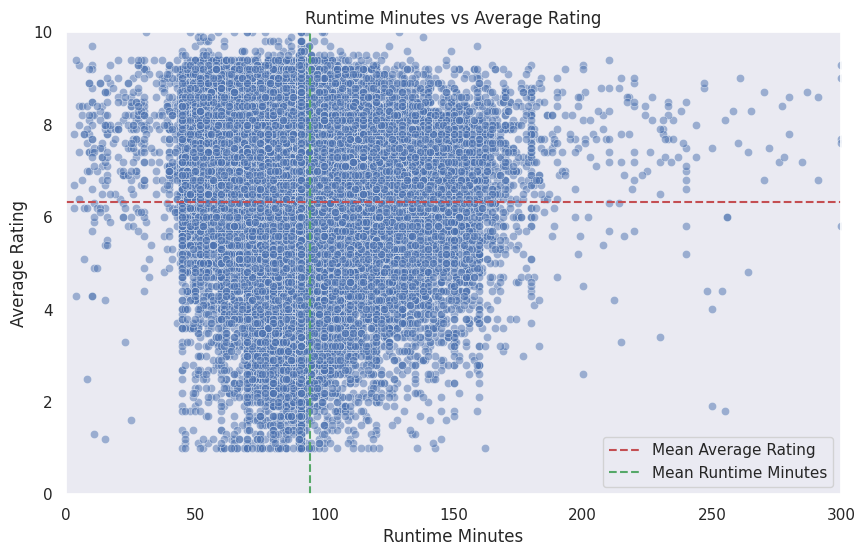

In [117]:
# plot of average rating against revenue

plt.figure(figsize=(10, 6))
sns.scatterplot(data=movie_df, x='runtime_minutes', y='average_rating', alpha=0.5)
plt.title('Runtime Minutes vs Average Rating')
plt.xlabel('Runtime Minutes')
plt.ylabel('Average Rating')
plt.xlim(0, 300) # limit x-axis to 300 minutes
plt.ylim(0, 10) # limit y-axis to 10 ratings
plt.axhline(y=movie_df['average_rating'].mean(), color='r', linestyle='--', label='Mean Average Rating') # mean line for average rating
plt.axvline(x=movie_df['runtime_minutes'].mean(), color='g', linestyle='--', label='Mean Runtime Minutes') # mean line for runtime minutes
plt.legend()
plt.grid()
plt.show()

##### 🔎 **Key Observation**:
- **General distribution**: The data points are fairly dispersed, indicating that there is **no strong** or **obvious** correlation between the movie runtime and it's average rating

- **Typical runtimes**: Majority of the movies cluster between **50 and 150 minutes** in runtime, suggesting that most of the films are of typical feature-length duration.

- **Higher runtime**: 
    - Movies exceeding 150 minutes are less common, and do not show a consistent trend towards higher ratings
    - Some longer movies achieve high ratings, but others perform moderately or poorly, indicating that runtime alone does not predict quality.

- **Horizontal and vertical mean lines**:
    - The **red dashed line** represents the **mean average rating** across all movies.
    - The **green dashed line** represents the **mean runtime in minutes**
    - Many movies fall **below the average rating line** even with runtimes near or above the average, further supporting the claim that runtime alone doesn't guarantee higher critical reception.

- **Outliers**: A few short movies **(below 60 minutes)** and a few very long films **(over 180 minutes)** exist, but they are relatively rare and show mixed ratings.

- 🎯**Summary implication**: 
    - There is no clear advantage in producing significantly longer movies if the goal is to achieve higher ratings.
    - Creative and storytelling quality likely play a larger role than runtime in influencing audience ratings.


#### 2. **Top 20 Movie Genres**
This bar plot displayes the 20 most common movie genres in the dataset based on the number of movies produced.

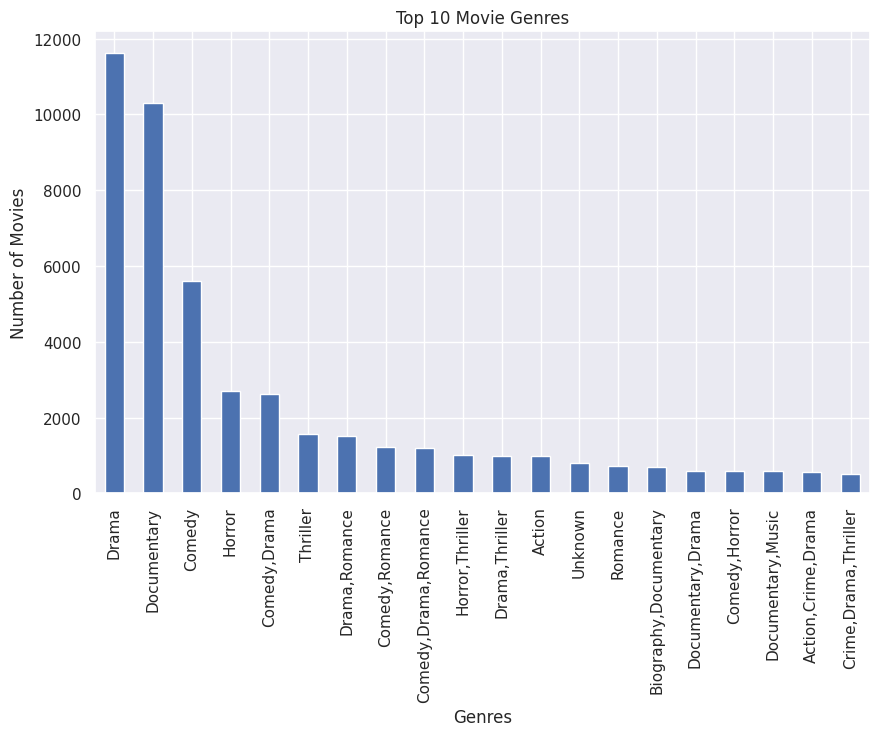

In [118]:
# bar plot of genre popularity
plt.figure(figsize=(10, 6))
movie_df['genres'].value_counts().head(20).plot(kind='bar')
plt.title('Top 10 Movie Genres')
plt.xlabel('Genres')
plt.ylabel('Number of Movies')
plt.show()

##### 🔎 **Key Observation**:
- **Genre dominance**
    - A few genres, likely including popular categories such as **Drama, 'Comedy, Drama', and 'Comedy, Drama, Romance'** dominate the dataset.
    - These genres have significanly more movies compared to others, reflecting **broad audience appeal** and **consistent market demand**

- **Steep drop-off**
    - After the top three to five genres, the number of movies per genre notably declines.
    - This suggests that while a number of genres are highly saturated, **niche genres** (such as documentary, horror, thriller) still maintain a smaller but steady presence.

- **Genre blending**
    - Majority of the entries combine multiple genres (e.g., 'Comedy, Drama'), indicating that **genre hybridity** is a common strategy to appeal to a bigger audience.

- 🎯**Summary implications**
    - For a new movie studio, it might be strategic to showcase popular genres such as **Drama, Comedy** to maximize potential reach and audience familiarity.
    - However, **overcrowding in top genres** also implies the competition is intense. Therefore, exploring **underserved genres or hybrid combinations** could offer differentiation and attract niche markets.
    - Genre popularity could also guide decisions in **story development, marketing tone and target demographics** for new films.

#### 3. **Top 20 Movies by Total Gross**
This bar plot highlights the top 20 highest-grossing movies in the dataset, ranked by their total revenue (calculated as the sum of domestic and foreign grosses).

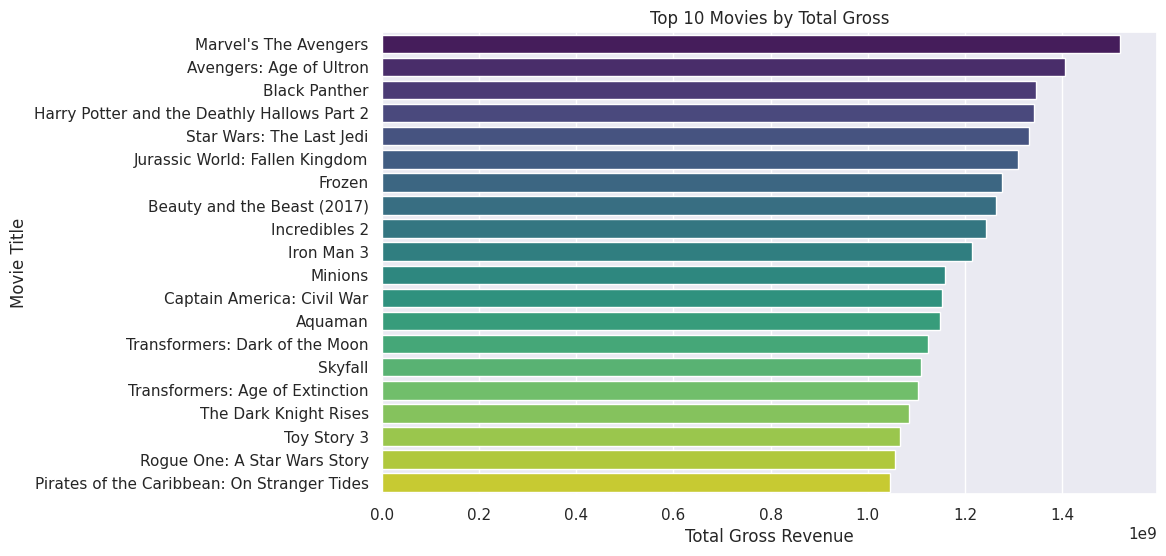

In [119]:
# plot for top 10 movies by total gross
plt.figure(figsize=(10, 6))
top_10_movies = movie_gross_df.nlargest(20, 'total_gross')
sns.barplot(data=top_10_movies, x='total_gross', y='title', palette='viridis', hue='title')
plt.title('Top 10 Movies by Total Gross')
plt.xlabel('Total Gross Revenue')
plt.ylabel('Movie Title')
plt.show()

##### 🔎 **Key Observation**:
- **Revenue leaders**
    - The movies displayed in the plot represent the **most commercially successful titles** in the dataset. These likely include major franchise films, or global blockbusters recognized for strong performance across global markets.

- **Wide range of earnings**
    - There is a noticeable spread in total gross revenue even among the top 20. This suggests that while all movies were financially successful, a few **significantly outperformed the rest**, likely generating billions in combined revenues.

- **Strong foreign markets**
    - For most of the blockbusters, a substantial portion of revenue may emanate from foreign markets, emphasizing the importance of international appeal and global distribution.

- **Title-based comparison**
    - Each bar in the plot is labeled with the movie's title (y-axis), making it easy to identify which films dominated the box office.

- 🎯**Summary implications**
    - Analyzing these top performing movies could offer valuable insights into what themes, genres, or production choices tend to resonate more profitably with audiences.

#### 4. **Top 10 Genres by Average rating**
This bar plot highlights the top 10 movie genres by their average ratings. It groups the data by genre and the mean of the average rating, uncovering the genres that have critical reception from the audience.

In [120]:
# display top 10 movie genres and average rating columns
top_10_genre_by_ratings = movie_df.groupby('genres')['average_rating'].mean().nlargest(10).reset_index()
top_10_genre_by_ratings.columns = ['Genres', 'Average Rating']
print("Top 10 Movie Genres by Average Rating:")
print(top_10_genre_by_ratings)

Top 10 Movie Genres by Average Rating:
                        Genres  Average Rating
0   Comedy,Documentary,Fantasy             9.4
1   Documentary,Family,Musical             9.3
2                History,Sport             9.2
3                    Game-Show             9.0
4                Music,Mystery             9.0
5      Comedy,Drama,Reality-TV             8.8
6  Documentary,News,Reality-TV             8.8
7       Documentary,News,Sport             8.8
8            Drama,Fantasy,War             8.8
9                  Drama,Short             8.8


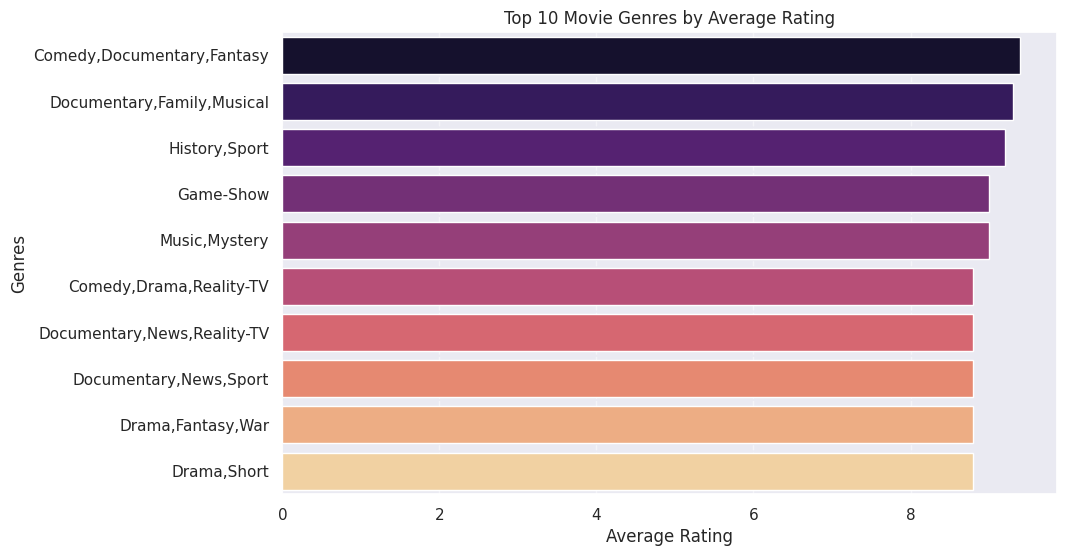

In [121]:
# plot the top 10 movie genres by average rating
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_genre_by_ratings, x='Average Rating', y='Genres', palette='magma', hue='Genres', legend=False)
plt.title('Top 10 Movie Genres by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Genres')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

##### 🔎 **Key Observation**
- Higher-rated genres, which include Documentary, Fantasy, History, etc, often focus on depth, storytelling, or real-world subjects that appeal to a larger audience.

- Genres such as Drama may also appeal to critics due to their emphasis on emotional depth and performance.

- Action or comedicic genres may score slightly lower on average, and hence do not appear in the plot.

- 🎯**Implications**: Focusing on these highly rated genres could aid the studio in obtaining critical acclaim or awards.

#### 5. **Top 10 Movie Genres by Number of votes**
This bar plot highlights the top 10 movie genres that have received the highest average number of votes from the audience, which serves as a proxy for audience engagement or popularity.

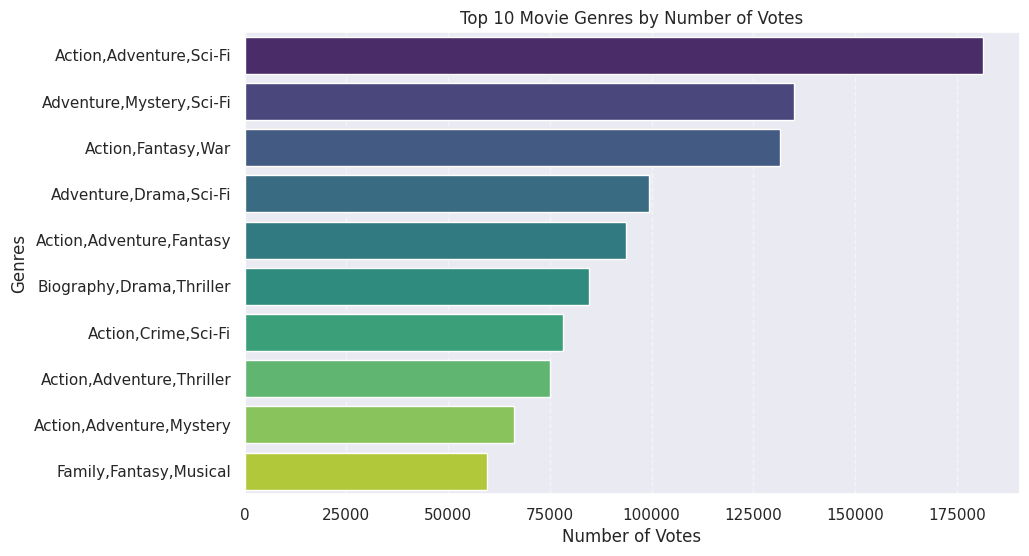

In [122]:
# plot top 10 movie genres by number of votes
top_10_genre_votes = movie_df.groupby('genres')['number_of_votes'].mean().nlargest(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_genre_votes, x='number_of_votes', y='genres', palette='viridis', hue='genres', legend=False)
plt.title('Top 10 Movie Genres by Number of Votes')
plt.xlabel('Number of Votes')
plt.ylabel('Genres')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

##### 🔎 **Key Observations**:
- A higher number of votes indicates that the genre has a larger popularity, making this an insightful attribute for analyzing gender appeal.

- **Higher audience interaction**
    - The genres displayed in the plot attracted the most viewer participation, with users voting on these films more frequently than others.
    - This implies strong public interest or high visibility for films with these genres.

- **Voting as a popularity metric**
    - The number of votes reflects both how widely a movie has been viewed and engaged with. Genres with high vote counts more often than not feature big-budget films, streaming visibility or strong fan bases

- **Contrast with ratings**
    - Some genres may appear in this list despite having lower average ratings. This distinction suggests that while these genres attract a huge audience, they may not always attract critical acclaim

- 🎯**Summary implications**
     - If the studio's objective is maximum audience engagement, producing content within the highly voted genres increases the chances of reaching a large audience.
     - This insight is valuable for marketing and platform release strategies.

#### 6. **Movie Production and Rating Trends Over the Years**
This analysis illustrates the trend in movie production and ratings over time, based on the number of movies released each year, as well as the average rating of the movies per year. Both visualizations give better insight into the trends in movie production and reception by audience.

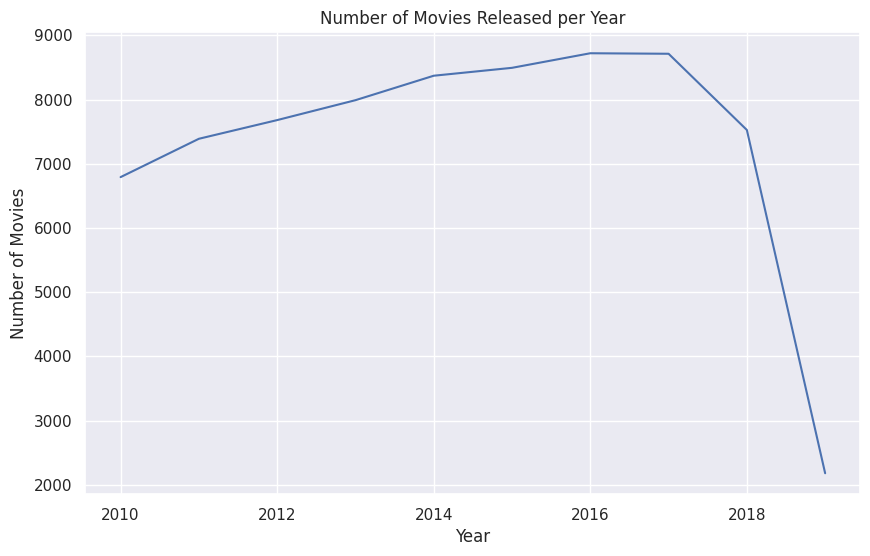

In [123]:
# plot for number o movies released per year
plt.figure(figsize=(10, 6))
movie_df['start_year'] = movie_df['start_year'].astype('Int64')
movies_per_year = movie_df.groupby('start_year').size()

# plot
movies_per_year.plot(kind='line')
plt.title('Number of Movies Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.show()

##### 🔎 **Interpretation**
- Between 2010 and 2017, the plot shows a general increase, which suggests a significant growth in movie production, likely fueled by expansion of global film industries, advancements in technology, etc.

- However, from 2017 onwards there has been a sharp decline in movie production. This may be attributed to:
    - Global crisis (2020 COVID-19 pandemic), which drastically slowed production and releases
    - Industry strikes and economic downturns


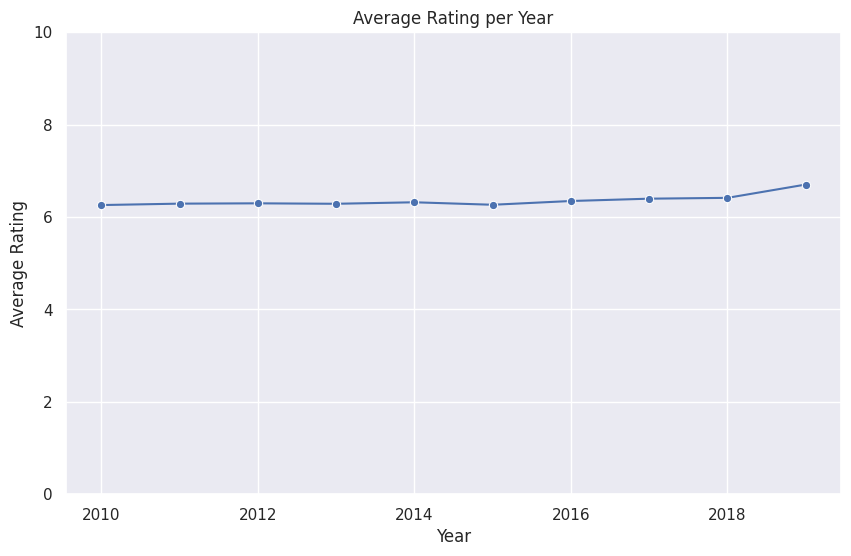

In [124]:
# average rating per year
average_rating_per_year = movie_df.groupby('start_year')['average_rating'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=average_rating_per_year, x='start_year', y='average_rating', marker='o')
plt.title('Average Rating per Year')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.ylim(0, 10) # limit y-axis to 10 ratings
plt.show()

#### 7. **Top 10 movie studios by domestic and foreign gross**
These bar plots illustrate the average domestic and foreign box office gross revenue for the top 10 film studios, offering insight into which studios consistently produce high-revenue films in each market.

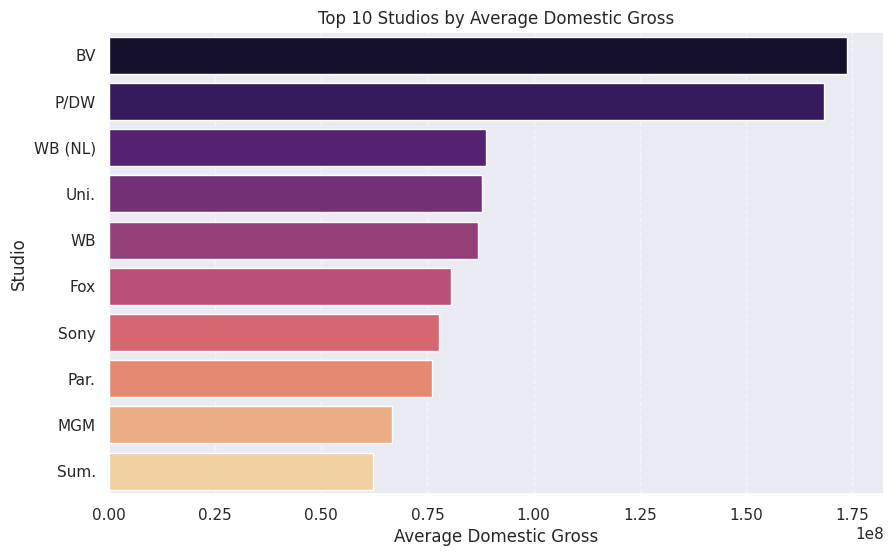

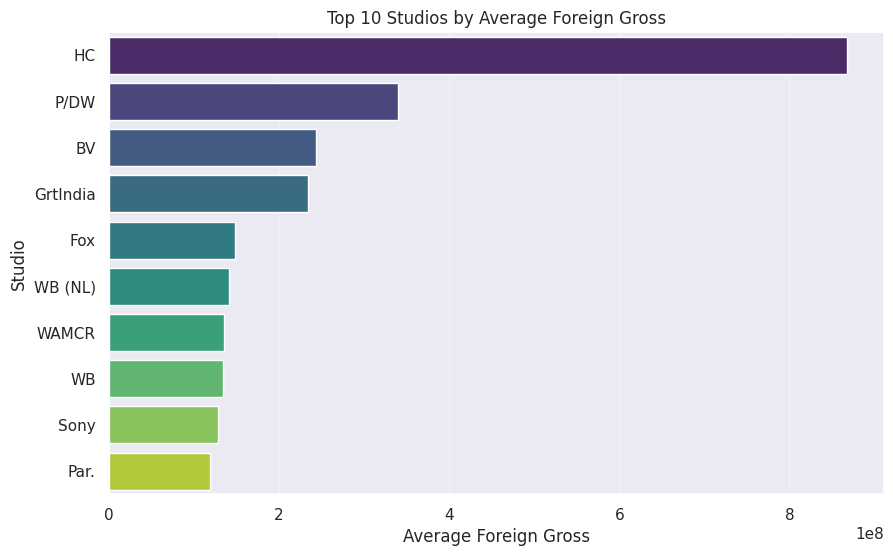

In [125]:
# top 10 studios by average domestic gross
top_10_studios_domestic = movie_gross_df.groupby('studio')['domestic_gross'].mean().nlargest(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_studios_domestic, x='domestic_gross', y='studio', palette='magma', hue='studio', legend=False)
plt.title('Top 10 Studios by Average Domestic Gross')
plt.xlabel('Average Domestic Gross')
plt.ylabel('Studio')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# top 10 studios by average foreign gross
top_10_studios_foreign = movie_gross_df.groupby('studio')['foreign_gross'].mean().nlargest(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_studios_foreign, x='foreign_gross', y='studio', palette='viridis', hue='studio', legend=False)
plt.title('Top 10 Studios by Average Foreign Gross')
plt.xlabel('Average Foreign Gross')
plt.ylabel('Studio')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

##### 🔎 **Interpretation**
1. **Top 10 studios by average domestic gross:**
    - Studios at the top (BV, Warner Bros (WB), Universal) tend to have a strong U.S. domestic market presence and successful domestic distribution strategies.
    - The high average domestic gross suggests these studios regularly produce captivating content, often driven by well-known franchises, high budgets, and extensive marketing.

2. **Top 10 studios by average foreign gross:**
    - Studios performing well in foreign markets often distribute films with broad international appeal, such as drama, comedy, or documentary genres.
    - Some studios (e.g., HC) may perform better on a global scale than domestically, indicating strong overseas distribution networks or global content strategy.

##### ✨ **Comparative Insights**
- A studio appearing in both plots (e.g., Warner Bros, Sony, Fox) demonstrates well-rounded global performance, while others might be more regionally dominant.
- Variability between domestic and foreign earnings also hints as cultural preferences and how studios tailor content for different markets.

#### 8. **Distribution of Movie Ratings by Number of Movies**
This histogram, overlaid with a Kernel Density Estimate (KDE) curve, visualizes how average movie ratings are distributed across the dataset. This helps in establishing the most common common movie rating for majority of the movies in the dataset.


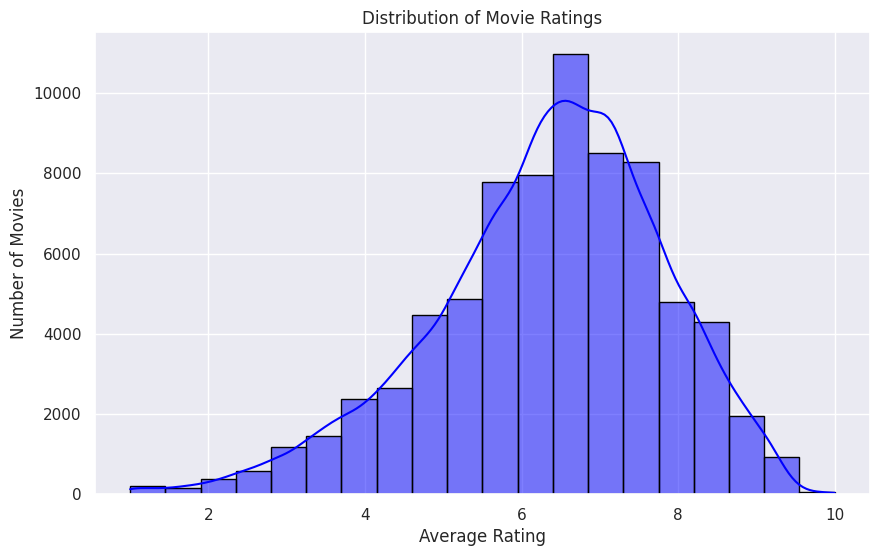

In [126]:
# plot for distribution of movie ratings
plt.figure(figsize=(10, 6))
average_rating_data = movie_df['average_rating']
sns.histplot(
    data=movie_df,
    x='average_rating',
    bins=20,
    kde=True,           # <<< THIS ADDS THE SMOOTH CURVE
    color='blue',
    edgecolor='black'
)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.show()

##### 🔎 **Key Observations**
- **Normal-like distribution**
    - The plot typically resembles a **bell curve**, suggesting a roughly **normal distrubution** of movie ratings centered around a **moderate average**(commonly between 6.0 and 7.5)

- **Rating concentration**
    - A significant number of movies cluster between **6 and 8**, indicating that most films are rated above average, but not necessarily outstanding. This reflects a tendency for ratings to skew positively, especially on public platforms.

- **Few extreme ratings**
    - Very few movies score **below 4 or above 9**, highlighting the rarity of univesally disliked or critically acclaimed titles.
    - The **tails** of the distribution are thin, suggesting extreme ratings are **outliers**.

##### 🎯 **Implications**
- From a studio perspective:
    - "safe zone" ratings (6-8) are common; pushing past this zone requires high level of innovation, strong storytelling or unique themes.
    - It's paramount to understand what factors contribute to movies that fall in the higher-rated bracket (8+), since they can build long-term brand reputation.
    - Similarly, analyzing lower-rated films may help avoid common pitfalls in production or storytelling.
- This also informs **target setting**: Aiming for at least a 7.0 average rating would position a studio **above the median**, in terms of perceived quality.

#### 9. **Correlation Heatmap for Movie Features**
This heatmap visualizes the Pearson correlation coefficients between numerical features in the `movie_df` dataset:
- `average_rating`: mean rating received by a movie
- `number_of_votes`: how many users rated the movie
- `runtime_minutes`: the length of the movie
- `start_year`: the release year of the movie.

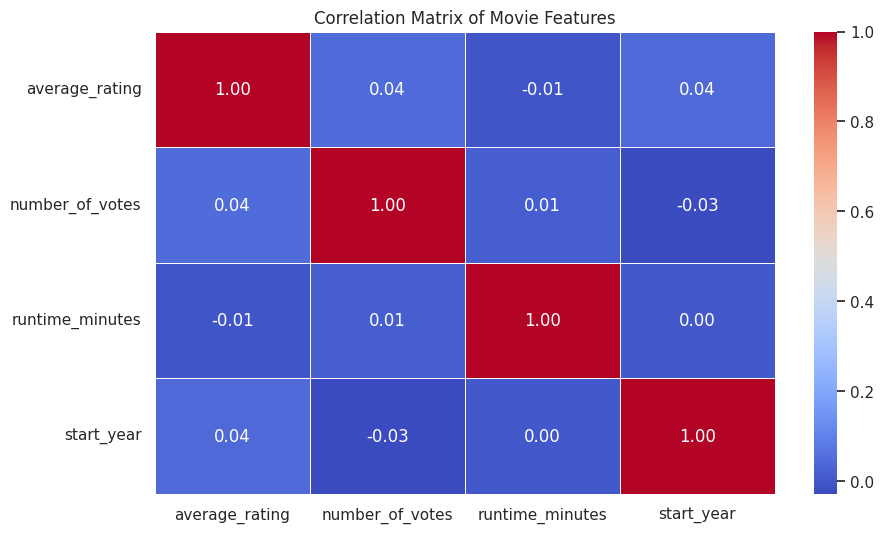

In [127]:
# correlation heatmap for movie_df

# set the numeric columns
numeric_cols = ['average_rating', 'number_of_votes', 'runtime_minutes', 'start_year']

# calculate the correlation matrix
corr_matrix = movie_df[numeric_cols].corr()

# plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Matrix of Movie Features')
plt.show()

- Each square in the heatmap represents the **correlation coefficient** between a pair of features, ranging from:
    - `+1`: perfect positive correlation

    - `0`: no correlation

    - `-1`: perfect negative correlation

- `movie_df[numeric_cols].corr()`: computes the **Pearson correlation matrix** between selected numeric features.

- `sns.heatmap()`: Visualizes the correlation matrix as a color-coded grid
    - `annot=True`: overlays numeric values in each square.

    - `cmap='coolwarm'`: color scale from cool(negative) to warm(positive)

    - `fmt='.2f'`: formats annotations to 2 decimal places.

    - `linewidth=0.5`: adds spacing between grid cells.

- This plot is useful in the following ways:
    - **Feature selection**: Helps identify redundant variables due to strong correlation.

    - **Pattern recognition**: Quickly highlights potential relationships worth deeper analysis (e.g., popularity vs ratings)

    - **Hypothesis generation**: for example, "Do longer movies generally receive better ratings?" can be tested

##### 🔎 **Key Observations**
1. `average_rating` vs `number_of_votes`:
    - Weak to moderate **positive relation** (0.04)

    - Suggests that movies with more votes tend to have slightly higher average ratings. Popularity might be associated with quality, though this is not a very strong claim.

2. `runtime_minutes` correlations:
    - Weak positive correlation with `average_rating`
    
    - This indicates that longer movies may receive slightly better ratings, perhaps due to more developed plots, but the effect is minor.

3. `start_year` has **little correlation** with other variables:
    - This suggests that neither runtime, votes, nor ratings have significantly changed over time in a linear manner.

    - This could indicate stability in viewer preferences, or inconsistent temporal trends.

#### 10. **Correlation Heatmap of Movie Gross Features**
This heatmap visualizes the Pearson correlation coefficients between numerical features in the `movie_gross_df` dataset:
- `domestic_gross`: Revenue earned in the domestic (U.S.) market
- `foreign_gross`: Revenue earned in international markets
- `total_gross`: Combined total of domestic and foreign gross
- `year`: The year of movie release

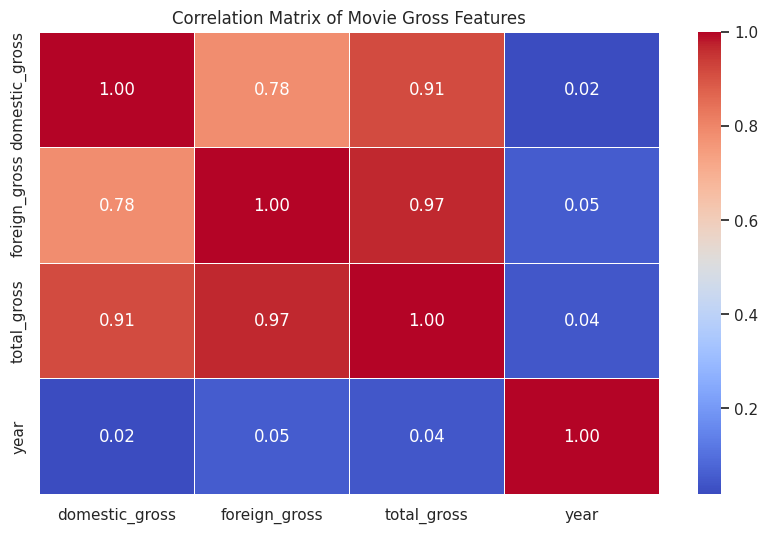

In [128]:
# correlation heatmap for movie_gross_df

# set the numeric columns
numeric_cols = ['domestic_gross', 'foreign_gross', 'total_gross', 'year']

# calculate the correlation matrix
corr_matrix = movie_gross_df[numeric_cols].corr()

# plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Matrix of Movie Gross Features')
plt.show()

- The Pearson correlation coefficient `(r)` ranges from:
    - `+1.00`: perfect positive correlation

    - `0.00`: no correlation

    - `-1.00`: perfect negative correlation

- Each cell in the heatmap shows how strongly or weakly two features are linearly related, with values annotated using `annot=True`

##### 🔎 **Key Observations**
1. **Strong positive correlation** between `domestic_gross` and `total_gross` **(r = 0.91)**
    - This is expected, since `total_gross` is the sum of domestic and foreign revenues

    - This indicates that domestic performance heavily influences overall gross.

2. **Stronger, close to perfect positive correlation** between `foreign_gross` and `total_gross` **(r = 0.97)**
    - This correlation is stronger than the correlation between `domestic_gross` and `total_gross`

    - This implies that foreign revenue contributes significantly towards total performance.

3. **Very weak correlation** between `year` and any revenue variables **(e.g r = 0.02 for year vs domestic_gross)**
    - This suggests that movie earnings have not shown a consistent linear progression over time.

    - This could be attributed to **fluctuating market trends, studio strategies, or the economic landscape**

#### 11. **Average Total Gross over the Years**
This line plot analyzes the change in average movie earnings over the years. Each data point represents the mean total gross (domestic + foreign) for all the movies in a given year.

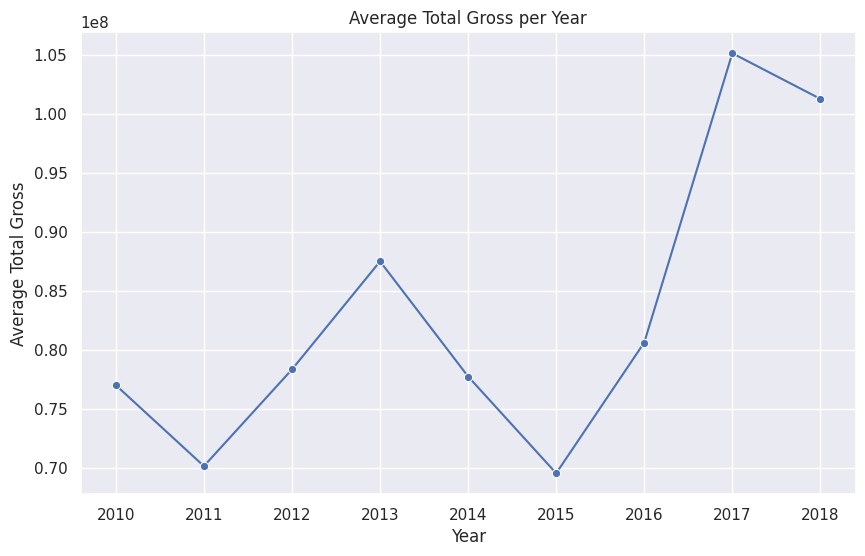

In [129]:
# calculate average total gross per year
average_total_gross_per_year = movie_gross_df.groupby('year')['total_gross'].mean().reset_index() # reset_index() converts the groupby object to a DataFrame

# plot the average gross per year
plt.figure(figsize=(10, 6))
sns.lineplot(data=average_total_gross_per_year, x='year', y='total_gross', marker='o')
plt.title('Average Total Gross per Year')
plt.xlabel('Year')
plt.ylabel('Average Total Gross')
plt.grid(True)
plt.show()

##### 🔎 **Key Observations**
1. 📉 **Decline from 2010 to 2011**
    - There was a slight drop in average total revenue between 2010 and 2011.

    - Possible causes:
        - 2010 was a strong year with blockbuster films. 2011 lacked equivalent blockbusters that captivated the audiences.

        - 3D fatigue: The 3D realm peaked in 2010 with Avatar, but by 2011, audiences grew weary of unnecessary 3D upcharges, leading to fewer premium ticket sales.
    
    - **Implication**: This suggests the risk of relying on a few top-performing titles to anchor a year's performance.

2. 📈 **Rise from 2011 to 2013**
    - There was a notable and consistent increase in the average total gross.

    - This was possibly attributed by:
        - 2012 was a major year with productions of **_The Avengers (MCU's crossover event), Skyfall, and The Dark Knight Rises_**

        - 2013 followed suite with successful sequels from **_Iron Man 3, Despicable Me 2_**. These two years produced blockbusters that led to an increase in revenue.

    - **Implication**:
        - This strongly demonstrates the value of sequel production, and shared universes

        - It also indicated studios successfully capitalized on global fan bases.

3. 📉 **Sharp decline from 2013 to 2015**
    - There was a sharp decline in average total revenue from 2013 to 2015, with 2015 registering the lowest average total gross.

    - 2014 in particular saw fewer high-performing ,ovies compared to 2013

    - This was possibly attributed by:
        - Streaming services like Netflix and Amazon Prime were rapidly gaining traction.

        - Change in audience tendencies: More viewers were opting to consume content from the comform of their homes, especially for mid-tier films

        - Studios began shifting mid-budget movies to digital platforms like Netflix, reducing the total revenue.

4. 📈 **Significant rise from 2016 to 2017**
    - There was a sharp upward trend from 2016 to 2017, with 2017 recording the highest average total gross from the plot.

    - This was attributed to:
        - 2017 was an exceptionally strong year in box office hits, especially from major franchises, with movies such as:
            - _Star Wars: The Last Jedi_
            - _The Fate of the Furious_
            - _Spider-Man: Homecoming_
        
        - Many of these films not only grossed high globally, but also performed exceptionally well domestically, significantly boosting average revenues.

        - Refined release strategies: Studios optimized release windows by reducing release overlaps between major studios.

        - Growth in international markets, particularly China.

5. 📉 **Slight decrease in 2018**
    - There was a slight decrease in revenue between 2017 and 2018.

    - Possible causes:
        - Fewer blockbuster hits: 2018 possibly had fewer breakout successes compared to 2017

        - Franchise fatigue: possible decrease in ticket sales for sequels

        - Pressure from streaming services, continuously reducing theatre-going for mid-range films

        - Global market disruptions

##### 💡 **Broader Implications**
1. **Investment Timing**
    - Studios may opt to launch major films during high grossing years or seasons.

2. **Diversification of film distribution**
    - From the years with poor gross (e.g., 2015), there is a need for alternative revenue channels such as:
        - Streaming deals

        - Digital-first releases

        - Licensing to third-party platforms

3. **Market Resilience and Risk Management**
    - Understanding year-over-year trends helps in forecasting revenue risks.

    - Studios may use this insight for contingency planning, insurance and pipeline decisions.

## ❓ **Hypothesis Testing**
In this section, we will perform a number of hypothesis tests on our cleaned data set.

### 1. **Do movies from major studios (e.g Warner Bros, Disney) consistently earn higher box office revenue than smaller studios?**
- In this hypothesis, we define our null and alternative hypothesis:
    - **Null Hypothesis ($H_{0}$)**: There is no significant difference in the success (e.g., box office revenue or IMDb ratings) between movies produced by major studios (Warner Bros, Universal, Disney) and independent films. Any observed differences are due to random variations.

    - **Alternative Hypothesis($H_{1}$)**: Movies produced by major studios are significantly more successful than independent films, meaning they tend to have higher box office revenue or IMDb ratings.

- The steps we will take in this test include:
    1. **Categorize Studios**: Define "major" studios, and classify others as "smaller"

    2. **Prepae the Data**: Filter relevant columns and clean data.

    3. **Perform a T-test**: Compare the mean revenue of major studios vs smaller studios.

    4. **Visualize the results**: Use boxplots for comparison.

T-Statistic: 7.01
P-Value: 0.00
Reject the null hypothesis: Major studios earn significantly higher revenue.


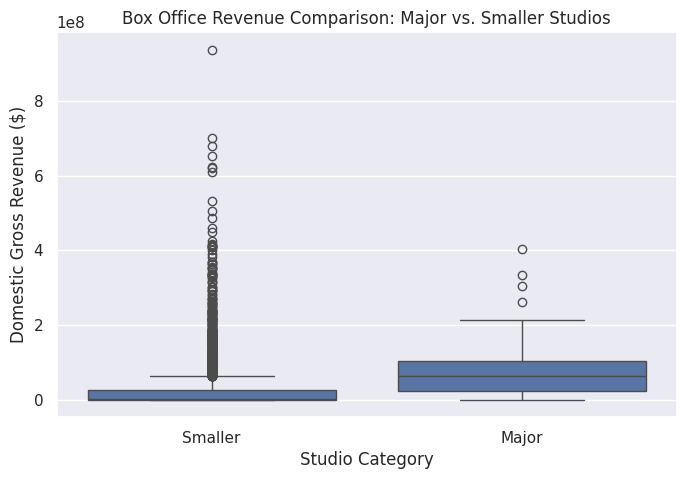

In [130]:
# Load cleaned dataset
movie_df= pd.read_csv("data/cleaned_data/cleaned_movie_dataset.csv")
movie_gross_df = pd.read_csv("data/cleaned_data/cleaned_movie_gross_dataset.csv")

# Define major studios
major_studios = ["Warner Bros.", "Disney", "Universal", "Paramount", "Sony", "20th Century Fox"]
movie_gross_df["studio_category"] = movie_gross_df["studio"].apply(lambda x: "Major" if x in major_studios else "Smaller")

# Filter relevant columns
df_major = movie_gross_df[movie_gross_df["studio_category"] == "Major"]["domestic_gross"]
df_smaller = movie_gross_df[movie_gross_df["studio_category"] == "Smaller"]["domestic_gross"]

# Perform t-test
t_stat, p_value = stats.ttest_ind(df_major, df_smaller, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_value:.2f}")

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis: Major studios earn significantly higher revenue.")
else:
    print("Fail to reject the null hypothesis: No significant difference in revenue.")

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(x="studio_category", y="domestic_gross", data=movie_gross_df)
plt.title("Box Office Revenue Comparison: Major vs. Smaller Studios")
plt.ylabel("Domestic Gross Revenue ($)")
plt.xlabel("Studio Category")
plt.show()

#### 🔎**Key Observation**
- From the T-test carried out, we can see that the p_value obtained is less than the standard significant value, ${\alpha}$ = 0.05, which indicates that we reject the Null hypothesis ($H_{0}$) ✅

- In addition, the boxplot visualization shows that the movies from the major studios earn a higher domestic revenue than the movies from the smaller studios, however the disparity in revenue is not as significant and huge.

- This still gives us the confidence to claim that movies from major studios earn a higher domestic revenue that movies from smaller studios. This can provide a guiding strategy in the development of a new movie studio, where we can consider modeling the new studio after the practices or genres typical of major studios in the market to improve the chances of commercial breakthrough.

### 2. **Testing Genre Success**
#### ❓ **Question**: Do some genres consistently earn higher ratings than others?

- In this test, we set the Null and Alternative Hypothesis as follows:
    - **Null Hypothesis ($H_{0}$)**: There is no significant difference in average ratings across genres

    - **Alternative Hypothesis ($H_{1}$)**: At least one genre has a significantly different average rating

- The steps we will take in this test include:
    - **Prepare the data**: Use the average rating and genre columns from the dataset

    - **Perform the statistical test**: Conduct the ANOVA (Analysis of Variance) test.

    - **Visualize the results**: Use a bar plot to visualize the results.

In [131]:
## import stats
from scipy.stats import f_oneway

# group the data by genre
# grouped_data = movie_df.groupby('genres')['average_rating'].apply(list)
grouped_data = [group['average_rating'].values for _, group in movie_df.groupby('genres')]

# perform the ANOVA test
f_stat, p_value = f_oneway(*grouped_data)

# print the results
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_value:.2f}")

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in average ratings among genres.")
else:
    print("Fail to reject the null hypothesis: No significant difference in average ratings among genres.")

# # Visualization
# plt.figure(figsize=(10, 6))
# plt.bar(grouped_data.index, [np.mean(ratings) for ratings in grouped_data], color='skyblue')
# plt.title("Average Ratings by Genre")
# plt.xlabel("Genres")
# plt.ylabel("Average Rating")
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()


F-Statistic: 26.98
P-Value: 0.00
Reject the null hypothesis: There is a significant difference in average ratings among genres.


#### 🔎 **Key Observation**
- From the T-test carried out, we can see that the p_value obtained is less than the standard significant value, ${\alpha}$ = 0.05, which indicates that we reject the Null hypothesis ($H_{0}$) ✅

- We can therefore conclude that there is a significant difference in ratings between genres.

### 3. **Runtime Impact on Movie Ratings**
#### ❓ **Question**: Do longer movies tend to receive higher ratings?

- In this test, we set the Null and Alternative Hypothesis as follows:
    - **Null Hypothesis ($H_{0}$)**: There is no significant correlation between movie runtime and ratings.

    - **Alternative Hypothesis ($H_{1}$)**: There is a statistically significant correlation

- The steps we will take in this test include:
    - **Prepare the data**: Use the runtime (minutes) and average ratings from the dataset

    - **Perform the statistical test**: Conduct the Pearson correlation test to look for correlation between the two attributes
        - Calculate the Pearson correlation (r)
        - Calculate the P_value (used to reject/accept the Null hypothesis)

    - **Visualize the results**: Use a regression plot to analyze the linear relationship between runtime and average ratings.

Pearson Correlation Coefficient: -0.01
P-Value: 0.07
Fail to reject the null hypothesis: No significant correlation between runtime and average rating.


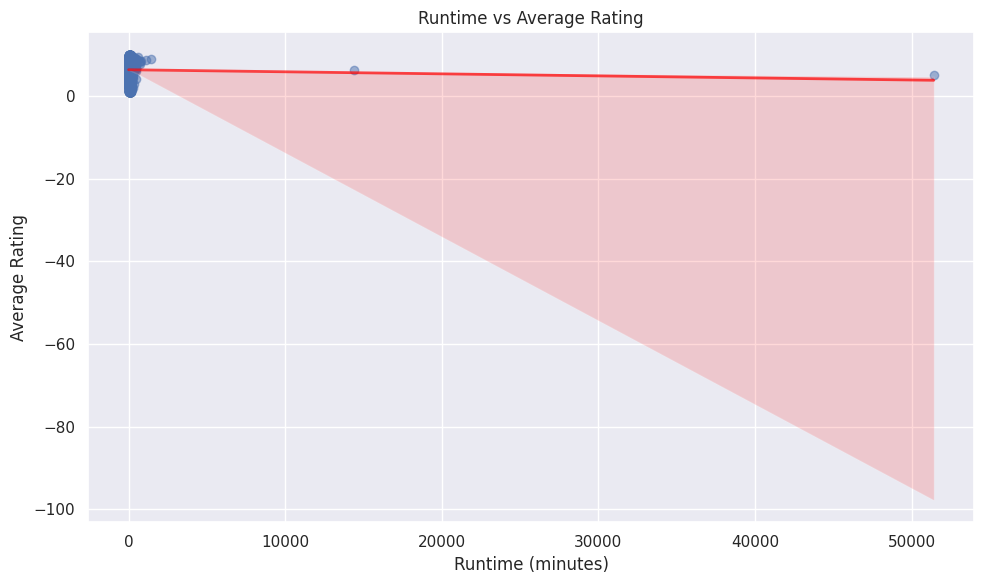

In [132]:
from scipy.stats import pearsonr

# perform the Pearson correlation test
corr, p_value = pearsonr(movie_df['runtime_minutes'], movie_df['average_rating'])

# print the results
print(f"Pearson Correlation Coefficient: {corr:.2f}")
print(f"P-Value: {p_value:.2f}")

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant correlation between runtime and average rating.")
else:
    print("Fail to reject the null hypothesis: No significant correlation between runtime and average rating.")

# Visualization
plt.figure(figsize=(10, 6))
sns.regplot(
    data = movie_df,
    x = 'runtime_minutes',
    y = 'average_rating',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red', 'alpha':0.7, 'lw':2}
)
plt.title('Runtime vs Average Rating')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()


#### 🔎 **Key Observation**
- **Pearson Correlation Coefficient (r)** measures the strength and direction of a linear relationship between two attributes (runtime & average rating).
    - `r > 0`: Positive relationship
    - `r < 0`: Negative relationship
    - `r = 0`: No relationship

- From our analysis, we have obtained r as `-0.01`, which is less than 1. This implies that there is a negative linear relationship between runtime and average ratings.

- Additionally, we have obtained the P_value as `0.07`. This implies that we accept the Null hypothesis, indicating that there is no significant correlation between runtime and average rating.

## 📝 **Summary of Key Insights, Recommendations and Conclusion.**

### 💡 **Key Insights**
1. 📺 **Genre Performance**:
    - Drama and Comedy dominate in frequency, suggesting strong audience appeal.
    - Documentary and History receive high IMDb ratings, indicating strong critical reception.
    - Hybrid genres (e.g., Comedy-Drama) are popular, blending different storytelling styles effectively.

2. 📽️ **Box Office Trends**:
    - High-grossing movies earn more revenue internationally than domestically, emphasizing global reach.
    - Major studios consistently lead in revenue, implying that brand influence plays a crucial role.

3. ⌛ **Runtime vs. Ratings**:
    - There is No strong correlation exists between longer runtimes and higher IMDb ratings.
    - Most successful movies fall between 90–150 minutes, suggesting an optimal length for audience engagement.

4. 📅 **Release Timing & Revenue Patterns**:
    - Revenue fluctuates across years, with some time periods generating substantially higher box office earnings.
    - Holiday season releases often align with spikes in revenue.

### 🎯 **Recommendations**
1. 🎭 **Genre Strategy**: Prioritize genres with strong audience interest (Drama, Comedy) but consider niche high-rated genres (Documentary, History) for critical success.

2. 📈 **International Market Focus**: Given the substantial revenue contribution from foreign markets, invest in global distribution strategies.

3. 💲 **Budget Optimization**: Spending more does not always guarantee profitability—focus on smart budget allocation based on past successful films.

4. 📅 **Strategic Release Planning**: Avoid overcrowded periods, leverage seasonal trends for maximum visibility.

### 📑 **Conclusion**
For a new movie studio, the best approach is a data-driven strategy that balances popular genres, efficient budget allocation, and international market optimization. Creative storytelling matters more than runtime, and well-timed releases enhance success. Adopting these insights will ensure competitive positioning in the industry.
